# Simulated Annealing Repeat Reliability

This companion notebook shows the repeat-reliability analysis from the Simulated Annealing tutorial as a focused, reusable example. It uses the bundled `results/all_raw_runs.pkl` data and the same best/random performance-ratio convention to define success.

Load a small set of real Simulated Annealing run rows, then compute the per-instance best and random baselines used to turn a performance-ratio target into an energy threshold.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import dimod
import numpy as np
import pandas as pd

from reliability_analysis import (
    DEFAULT_QUALITY_TARGET,
    attach_quality_thresholds,
    load_selected_raw_runs,
)

example_dir = Path.cwd()
instance_ids = [0, 1, 2]
quality_target = DEFAULT_QUALITY_TARGET
num_reads = 1000
num_variables = 100


def random_energy_for_instance(instance_id, *, num_reads=1000, num_variables=100):
    np.random.seed(instance_id)
    J = np.random.rand(num_variables, num_variables)
    J = np.triu(J, 1)
    h = np.random.rand(num_variables)
    model_random = dimod.BinaryQuadraticModel.from_ising(h, J, offset=0.0)
    samples = dimod.RandomSampler().sample(
        model_random,
        num_reads=num_reads,
        seed=instance_id,
    )
    return float(np.asarray(samples.data_vectors["energy"]).mean())


runs = load_selected_raw_runs(example_dir, instance_ids)
instance_baselines = {}
for instance_id in instance_ids:
    instance_runs = runs[runs["instance"] == instance_id]
    instance_baselines[instance_id] = {
        "best_value": float(instance_runs["energy"].min()),
        "random_value": random_energy_for_instance(
            instance_id,
            num_reads=num_reads,
            num_variables=num_variables,
        ),
    }

baseline_table = (
    pd.DataFrame.from_dict(instance_baselines, orient="index")
    .rename_axis("instance")
    .reset_index()
)
baseline_table

,instance,best_value,random_value
0,0,-239.359143,-1.207017
1,1,-244.676830,0.621088
2,2,-237.949914,-1.033347


Attach the derived energy threshold, run the public `stochastic_benchmark.run_RepeatReliability` workflow through the helper, and display compact diagnostics for selected resources.

In [2]:
import stochastic_benchmark as SB

from reliability_analysis import (
    run_reliability_analysis,
    select_reliability_diagnostics,
)

reliability_runs = attach_quality_thresholds(
    runs,
    instance_baselines,
    quality_target=quality_target,
)

benchmark = SB.stochastic_benchmark(
    parameter_names=["sweeps"],
    here=str(example_dir),
    instance_cols=["instance"],
    response_key="energy",
    response_dir=-1,
    recover=False,
    smooth=False,
)

report = run_reliability_analysis(
    benchmark,
    reliability_runs,
    quality_target=quality_target,
    relative_error_threshold=0.10,
)
diagnostics = select_reliability_diagnostics(report)

assert not diagnostics.empty
assert report["reliability_status"].eq("needs_more_trials").any()
assert report["statistically_unresolved"].any()

diagnostics

,instance,sweeps,current_resource,current_repeats,required_repeats,additional_repeats_required,p_ci_lower,p_ci_upper,R_c,R_c_ci_lower,R_c_ci_upper,R99,R99_ci_lower,R99_ci_upper,CETS,CETS_ci_lower,CETS_ci_upper,reliability_status,statistically_unresolved
0,0,1,1000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,2404.522302,995.194736,inf,needs_more_trials,False
112,0,2,2000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,4809.044604,1990.389472,inf,needs_more_trials,False
178,0,3,3000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,7213.566906,2985.584208,inf,needs_more_trials,False
199,0,4,4000,1000,94778,93778,0.000581,0.009222,937.162094,497.041900,7918.085805,937.162094,497.041900,7918.085805,3748.648377,1988.167601,3.167234e+04,needs_more_trials,False
542,1,480,480000,1000,1747,747,0.976412,0.991869,1.111295,1.000000,1.229027,1.111295,1.000000,1.229027,533.421595,480.000000,5.899328e+02,needs_more_trials,True
530,1,420,420000,1000,1568,568,0.972739,0.989564,1.159604,1.009352,1.278394,1.159604,1.009352,1.278394,487.033529,423.927877,5.369256e+02,needs_more_trials,True
536,1,450,450000,1000,1568,568,0.972739,0.989564,1.159604,1.009352,1.278394,1.159604,1.009352,1.278394,521.821638,454.208440,5.752774e+02,needs_more_trials,True
532,1,430,430000,1000,1519,519,0.971528,0.988783,1.174840,1.025577,1.294010,1.174840,1.025577,1.294010,505.181075,440.998070,5.564245e+02,needs_more_trials,True
974,2,990,990000,1000,1297,297,0.964367,0.983990,1.259432,1.113833,1.381073,1.259432,1.113833,1.381073,1246.837323,1102.694375,1.367262e+03,needs_more_trials,True
945,2,850,850000,1000,1268,268,0.963189,0.983176,1.272606,1.127352,1.394682,1.272606,1.127352,1.394682,1081.715110,958.249200,1.185480e+03,needs_more_trials,True


Generate paper-style diagnostic plots from the repeat-reliability report: `R99` estimates with confidence intervals, `CETS` estimates with confidence intervals, current versus required repeats, relative error, and the per-instance sweep count with the lowest CETS.


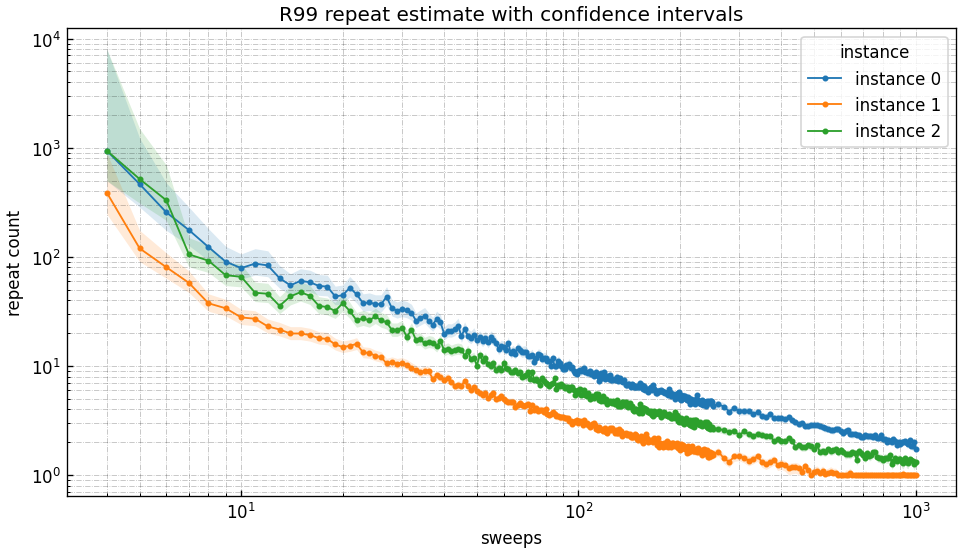

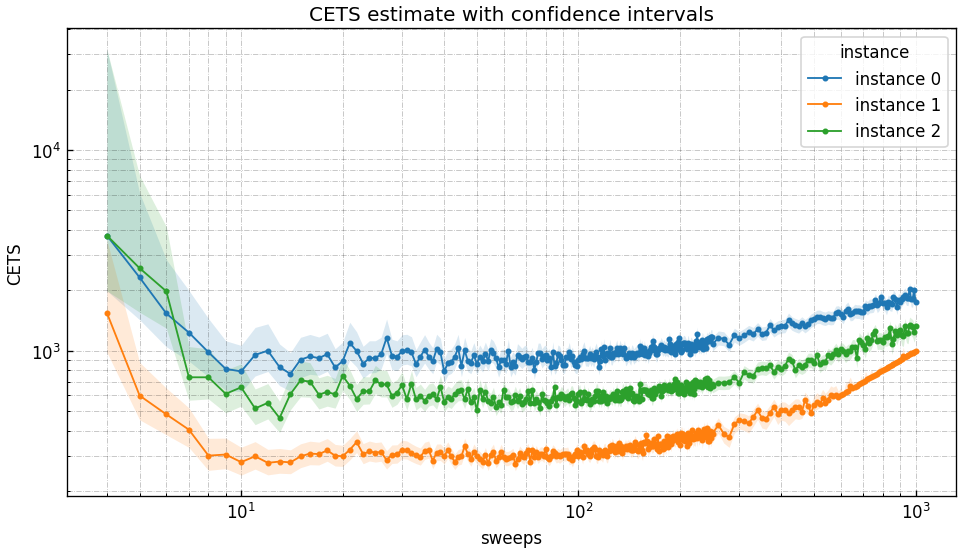

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})
plot_report = (
    report.sort_values(["instance", "sweeps"])
    .replace([np.inf, -np.inf], np.nan)
)


def _finite_interval_frame(metric, lower, upper):
    columns = ["instance", "sweeps", metric, lower, upper]
    return plot_report.dropna(subset=[metric, lower, upper]).loc[:, columns]


def _plot_metric_interval(metric, lower, upper, ylabel, title):
    interval_frame = _finite_interval_frame(metric, lower, upper)
    fig, ax = plt.subplots(figsize=(8, 4.6), constrained_layout=True)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for color_index, (instance_id, group) in enumerate(interval_frame.groupby("instance", sort=True)):
        group = group.sort_values("sweeps")
        color = colors[color_index % len(colors)]
        sweeps = group["sweeps"].to_numpy(dtype=float)
        estimates = group[metric].to_numpy(dtype=float)
        lower_bounds = group[lower].to_numpy(dtype=float)
        upper_bounds = group[upper].to_numpy(dtype=float)
        ax.plot(
            sweeps,
            estimates,
            marker="o",
            markersize=2.6,
            linewidth=1.1,
            color=color,
            label=f"instance {instance_id}",
        )
        ax.fill_between(
            sweeps,
            lower_bounds,
            upper_bounds,
            color=color,
            alpha=0.16,
            linewidth=0,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("sweeps")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(title="instance")
    return fig, ax


r99_fig, r99_ax = _plot_metric_interval(
    "R99",
    "R99_ci_lower",
    "R99_ci_upper",
    "repeat count",
    "R99 repeat estimate with confidence intervals",
)
cets_fig, cets_ax = _plot_metric_interval(
    "CETS",
    "CETS_ci_lower",
    "CETS_ci_upper",
    "CETS",
    "CETS estimate with confidence intervals",
)
plt.show()


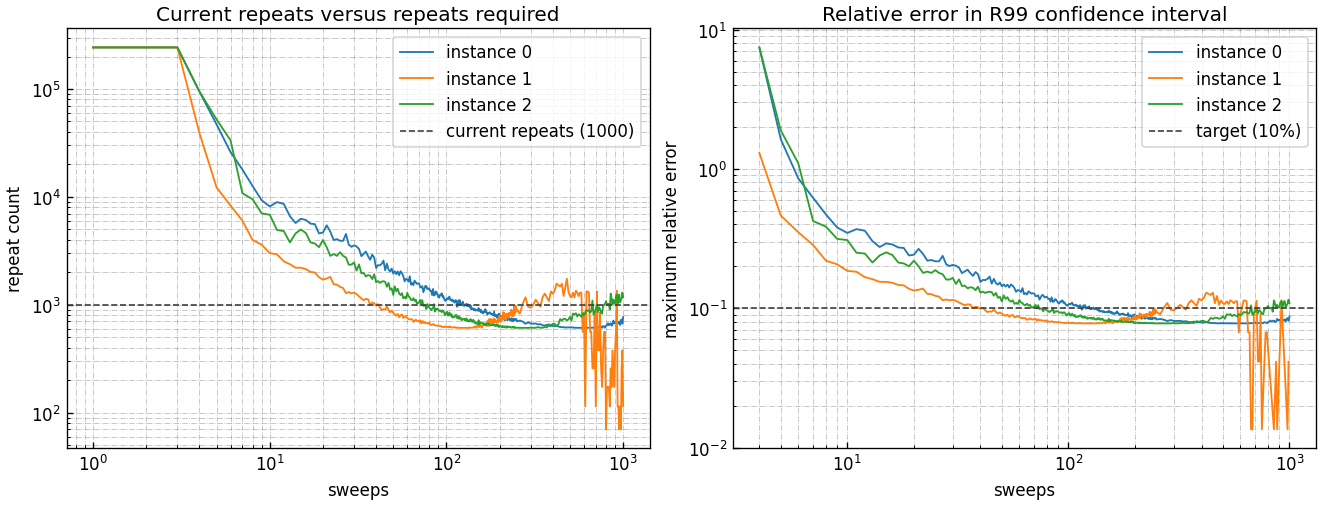

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
relative_error_threshold = float(report["relative_error_threshold"].iloc[0])

for color_index, (instance_id, group) in enumerate(plot_report.groupby("instance", sort=True)):
    group = group.sort_values("sweeps")
    color = colors[color_index % len(colors)]
    sweeps = group["sweeps"].to_numpy(dtype=float)
    axes[0].plot(
        sweeps,
        group["required_repeats"].to_numpy(dtype=float),
        color=color,
        linewidth=1.1,
        label=f"instance {instance_id}",
    )

    error_frame = group.loc[group["maximum_relative_error"].gt(0), ["sweeps", "maximum_relative_error"]].dropna()
    axes[1].plot(
        error_frame["sweeps"].to_numpy(dtype=float),
        error_frame["maximum_relative_error"].to_numpy(dtype=float),
        color=color,
        linewidth=1.1,
        label=f"instance {instance_id}",
    )

current_repeats = int(plot_report["current_repeats"].dropna().iloc[0])
axes[0].axhline(
    current_repeats,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    label=f"current repeats ({current_repeats})",
)
axes[1].axhline(
    relative_error_threshold,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    label=f"target ({relative_error_threshold:.0%})",
)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("sweeps")
axes[0].set_ylabel("repeat count")
axes[0].set_title("Current repeats versus repeats required")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("sweeps")
axes[1].set_ylabel("maximum relative error")
axes[1].set_title("Relative error in R99 confidence interval")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()
plt.show()


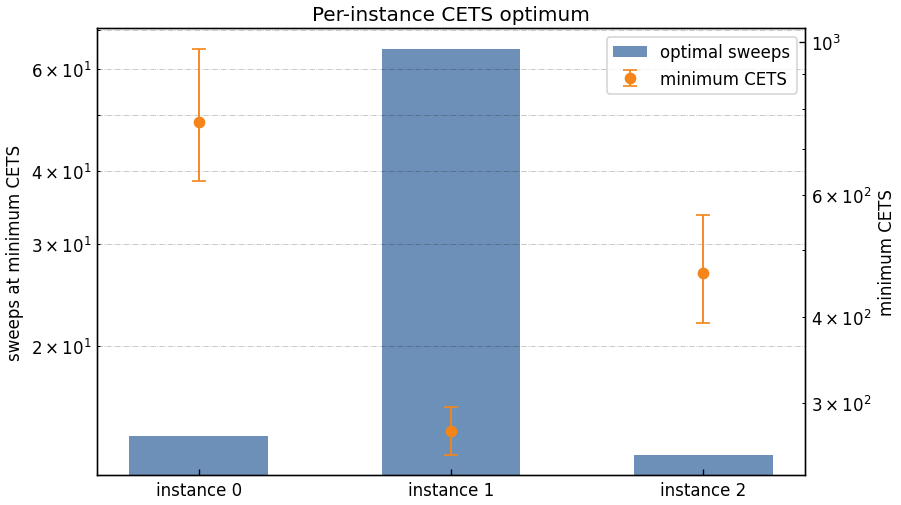

,instance,optimal_sweeps,R99,R99_ci_lower,R99_ci_upper,CETS,CETS_ci_lower,CETS_ci_upper,maximum_relative_error,reliability_status
46,0,14,54.793428,44.913922,69.887126,767.107998,628.794906,978.419770,0.275465,needs_more_trials
577,1,65,4.206733,3.882995,4.554694,273.437643,252.394660,296.055133,0.082715,reliable
685,2,13,35.564674,30.147138,43.140935,462.340767,391.912795,560.832161,0.213028,needs_more_trials


In [5]:
optimal_rows = (
    plot_report.dropna(subset=["CETS", "CETS_ci_lower", "CETS_ci_upper"])
    .sort_values(["instance", "CETS", "sweeps"])
    .groupby("instance", group_keys=False)
    .head(1)
    .sort_values("instance")
)
assert not optimal_rows.empty

x = np.arange(len(optimal_rows))
cets_estimates = optimal_rows["CETS"].to_numpy(dtype=float)
cets_lower_errors = np.maximum(
    cets_estimates - optimal_rows["CETS_ci_lower"].to_numpy(dtype=float),
    0.0,
)
cets_upper_errors = np.maximum(
    optimal_rows["CETS_ci_upper"].to_numpy(dtype=float) - cets_estimates,
    0.0,
)

fig, ax_sweeps = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax_sweeps.bar(
    x,
    optimal_rows["sweeps"].to_numpy(dtype=float),
    width=0.55,
    color="#4c78a8",
    alpha=0.82,
    label="optimal sweeps",
)
ax_sweeps.set_yscale("log")
ax_sweeps.set_ylabel("sweeps at minimum CETS")
ax_sweeps.set_xticks(x, [f"instance {int(instance)}" for instance in optimal_rows["instance"]])
ax_sweeps.grid(True, axis="y", which="both", alpha=0.25)

ax_cets = ax_sweeps.twinx()
ax_cets.errorbar(
    x,
    cets_estimates,
    yerr=np.vstack([cets_lower_errors, cets_upper_errors]),
    fmt="o",
    color="#f58518",
    capsize=4,
    linewidth=1.1,
    label="minimum CETS",
)
ax_cets.set_yscale("log")
ax_cets.set_ylabel("minimum CETS")
ax_cets.set_title("Per-instance CETS optimum")

handles, labels = ax_sweeps.get_legend_handles_labels()
cets_handles, cets_labels = ax_cets.get_legend_handles_labels()
ax_cets.legend(handles + cets_handles, labels + cets_labels, loc="upper right")
plt.show()

optimal_summary = optimal_rows.loc[
    :,
    [
        "instance",
        "sweeps",
        "R99",
        "R99_ci_lower",
        "R99_ci_upper",
        "CETS",
        "CETS_ci_lower",
        "CETS_ci_upper",
        "maximum_relative_error",
        "reliability_status",
    ],
].rename(columns={"sweeps": "optimal_sweeps"})
optimal_summary


Summarize the full report to confirm the example includes reliable, under-sampled, and statistically unresolved cases.

In [6]:
status_summary = (
    report["reliability_status"]
    .value_counts()
    .rename_axis("reliability_status")
    .reset_index(name="rows")
)
unresolved_rows = int(report["statistically_unresolved"].sum())
print(f"Rows with statistically unresolved intervals: {unresolved_rows}")
status_summary

Rows with statistically unresolved intervals: 102


,reliability_status,rows
0,reliable,682
1,needs_more_trials,293
